In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.figure(figsize=(10,6))
sns.set_style("whitegrid")

<Figure size 1000x600 with 0 Axes>

In [3]:
fund_master = pd.read_csv("../data/raw/01_fund_master.csv")

nav = pd.read_csv("../data/processed/clean_nav_history.csv")

transactions = pd.read_csv("../data/processed/clean_investor_transactions.csv")

performance = pd.read_csv("../data/processed/clean_scheme_performance.csv")

aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")

sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")

category = pd.read_csv("../data/raw/05_category_inflows.csv")

folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")

holdings = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

nav = pd.read_csv("../data/processed/clean_nav_history.csv")

print(nav.head())
print(nav.columns)


   amfi_code        date       nav
0     100016  2022-01-03  520.4608
1     100016  2022-01-04  515.0971
2     100016  2022-01-05  521.7239
3     100016  2022-01-06  515.7880
4     100016  2022-01-07  515.1639
Index(['amfi_code', 'date', 'nav'], dtype='str')


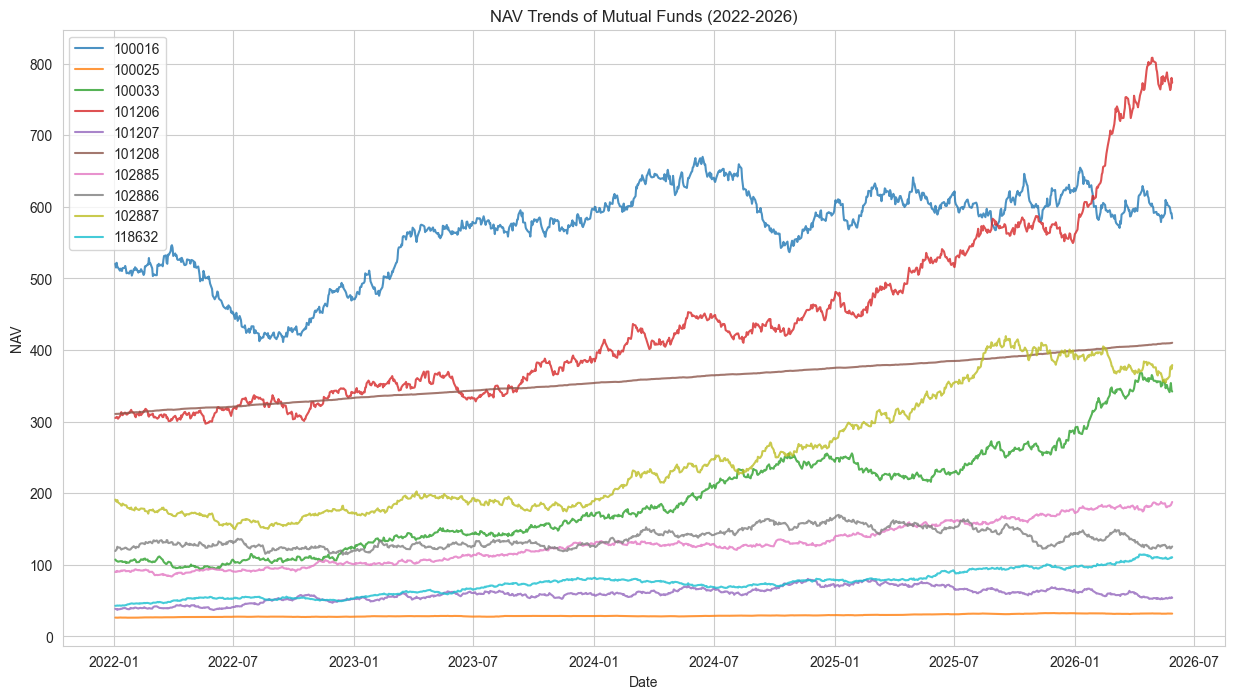

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Load cleaned NAV data
nav = pd.read_csv("../data/processed/clean_nav_history.csv")

# Convert date column
nav["date"] = pd.to_datetime(nav["date"])

# Plot first 10 schemes
plt.figure(figsize=(15,8))

for scheme in nav["amfi_code"].unique()[:10]:
    temp = nav[nav["amfi_code"] == scheme]

    plt.plot(
        temp["date"],
        temp["nav"],
        label=str(scheme),
        alpha=0.8
    )

plt.title("NAV Trends of Mutual Funds (2022-2026)")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.legend()
plt.grid(True)

plt.show()

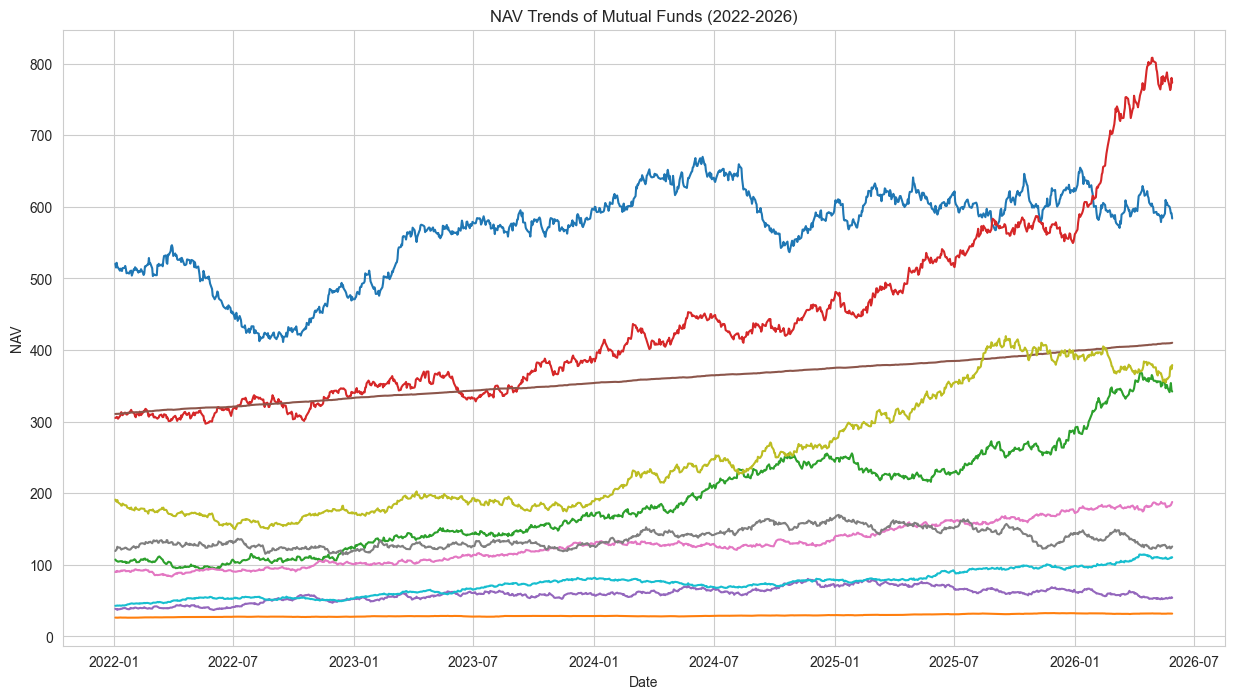

In [6]:
plt.figure(figsize=(15,8))

for scheme in nav["amfi_code"].unique()[:10]:
    temp = nav[nav["amfi_code"] == scheme]

    plt.plot(
        temp["date"],
        temp["nav"]
    )

plt.title("NAV Trends of Mutual Funds (2022-2026)")
plt.xlabel("Date")
plt.ylabel("NAV")

plt.savefig(
    "../reports/nav_trend.png",
    bbox_inches="tight"
)

plt.show()

In [7]:
aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")

print(aum.columns.tolist())
print(aum.head())

['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']
         date           fund_house  aum_lakh_crore  aum_crore  num_schemes
0  2022-03-31      SBI Mutual Fund            6.05     605000          186
1  2022-03-31  ICICI Prudential MF            4.65     465000          216
2  2022-03-31     HDFC Mutual Fund            4.35     435000          195
3  2022-03-31      Nippon India MF            2.70     270000          177
4  2022-03-31    Kotak Mahindra MF            2.70     270000          168


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")

aum["date"] = pd.to_datetime(aum["date"])

aum["year"] = aum["date"].dt.year

print(aum.head())

        date           fund_house  aum_lakh_crore  aum_crore  num_schemes  \
0 2022-03-31      SBI Mutual Fund            6.05     605000          186   
1 2022-03-31  ICICI Prudential MF            4.65     465000          216   
2 2022-03-31     HDFC Mutual Fund            4.35     435000          195   
3 2022-03-31      Nippon India MF            2.70     270000          177   
4 2022-03-31    Kotak Mahindra MF            2.70     270000          168   

   year  
0  2022  
1  2022  
2  2022  
3  2022  
4  2022  


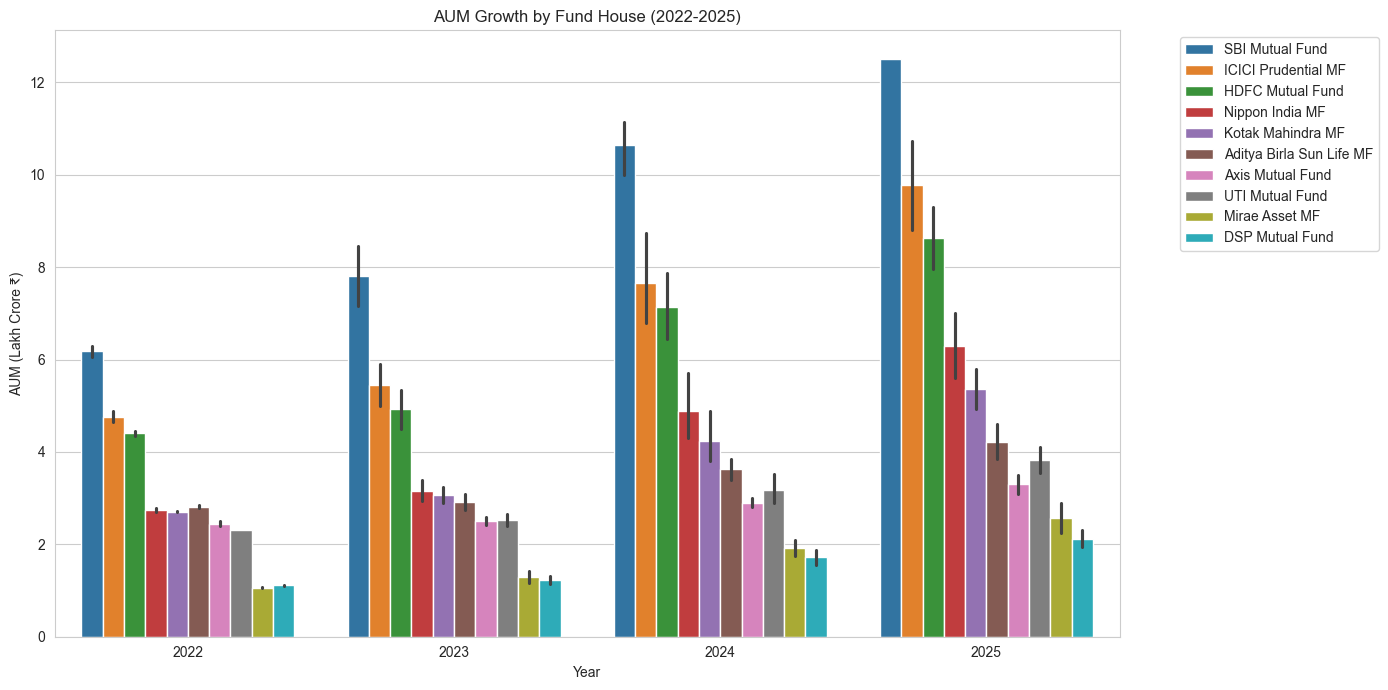

In [9]:
plt.figure(figsize=(14,7))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022-2025)")
plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore ₹)")

plt.legend(
    bbox_to_anchor=(1.05,1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    "../reports/aum_growth.png",
    bbox_inches="tight"
)

plt.show()

In [10]:
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")

print(sip.columns.tolist())
print(sip.head())

['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']
     month  sip_inflow_crore  active_sip_accounts_crore  \
0  2022-01             11517                       4.91   
1  2022-02             11438                       4.93   
2  2022-03             12328                       5.09   
3  2022-04             11863                       5.48   
4  2022-05             12286                       5.55   

   new_sip_accounts_lakh  sip_aum_lakh_crore  yoy_growth_pct  
0                   9.10                4.80             NaN  
1                   8.20                4.85             NaN  
2                  10.50                5.01             NaN  
3                   9.52                5.12             NaN  
4                   8.10                5.15             NaN  


In [22]:
category = pd.read_csv("../data/raw/05_category_inflows.csv")

print(category.columns.tolist())
print(category.head())

['month', 'category', 'net_inflow_crore']
     month         category  net_inflow_crore
0  2024-04        Large Cap            2413.0
1  2024-04          Mid Cap            3897.0
2  2024-04        Small Cap            3533.0
3  2024-04        Flexi Cap            4947.0
4  2024-04  Large & Mid Cap            4214.0


In [25]:
import pandas as pd
import plotly.express as px

sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")

sip["month"] = pd.to_datetime(sip["month"])

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflow Trend (2022-2025)"
)

# Highlight Dec 2025 milestone
milestone = sip.iloc[-1]

fig.add_annotation(
    x=milestone["month"],
    y=milestone["sip_inflow_crore"],
    text=f"₹{milestone['sip_inflow_crore']:,} Cr",
    showarrow=True
)

fig.show()

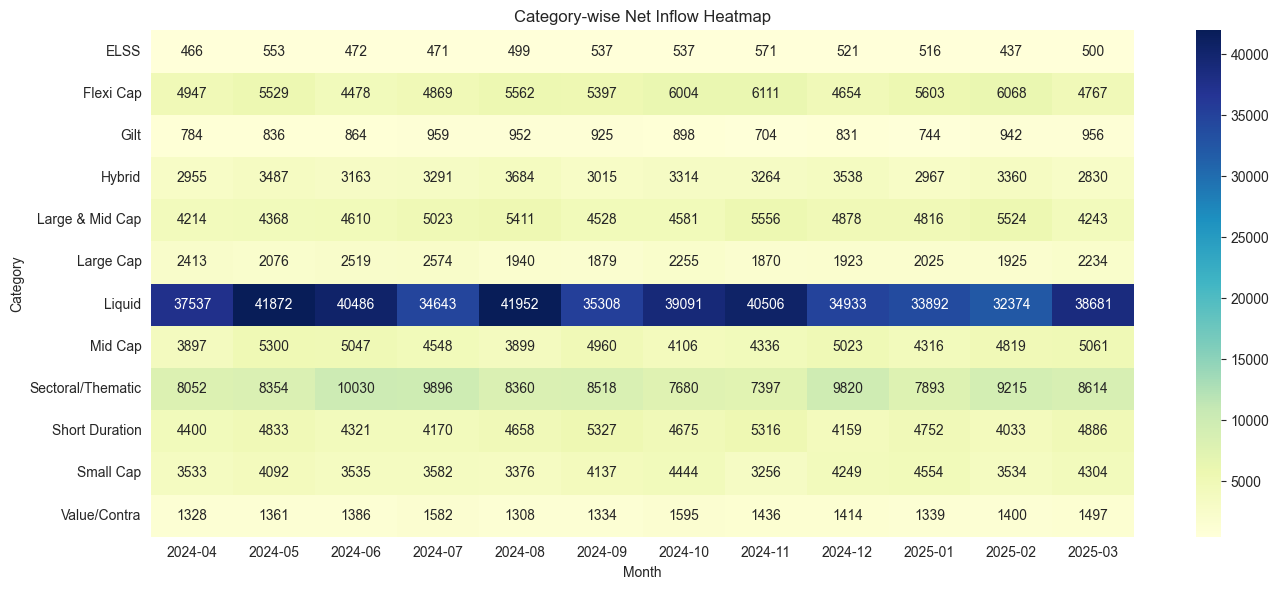

In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

category = pd.read_csv("../data/raw/05_category_inflows.csv")

# Create pivot table
pivot = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(14,6))

sns.heatmap(
    pivot,
    cmap="YlGnBu",
    annot=True,
    fmt=".0f"
)

plt.title("Category-wise Net Inflow Heatmap")
plt.xlabel("Month")
plt.ylabel("Category")

plt.tight_layout()

plt.show()

In [27]:
plt.savefig(
    "../reports/category_heatmap.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [28]:
transactions = pd.read_csv(
    "../data/processed/clean_investor_transactions.csv"
)

print(transactions.columns.tolist())
print(transactions["age_group"].value_counts())

['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']
age_group
26-35    13463
36-45     8146
18-25     4916
46-55     3779
56+       2474
Name: count, dtype: int64


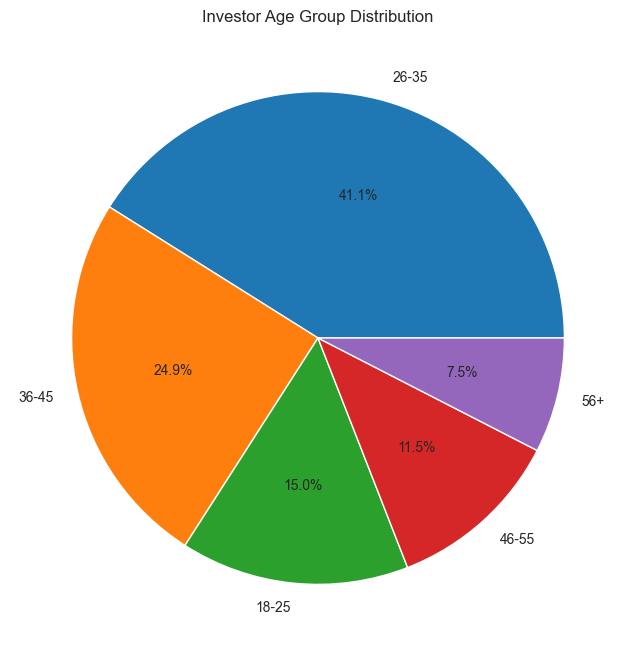

In [29]:
import matplotlib.pyplot as plt

age_counts = transactions["age_group"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%"
)

plt.title("Investor Age Group Distribution")
plt.savefig(
    "../reports/age_group_distribution.png",
    bbox_inches="tight"
)

plt.show()

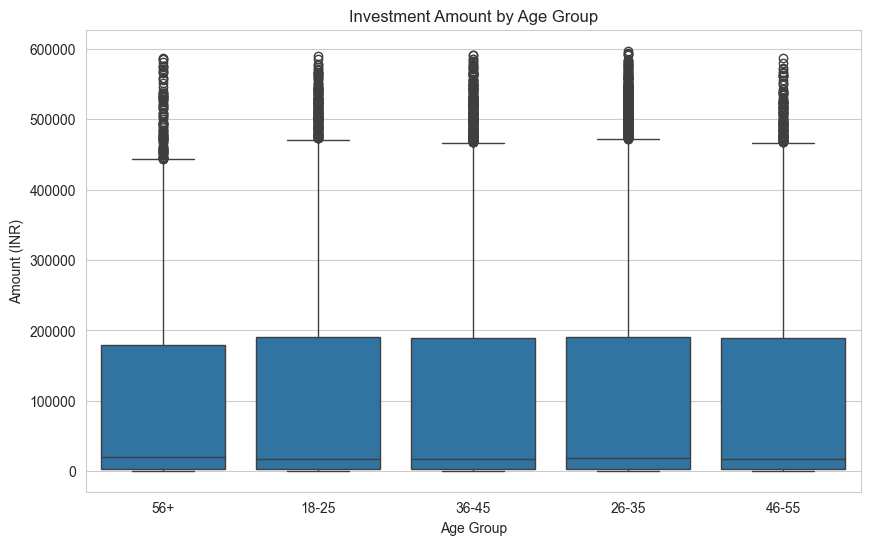

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.boxplot(
    data=transactions,
    x="age_group",
    y="amount_inr"
)

plt.title("Investment Amount by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Amount (INR)")
plt.savefig(
    "../reports/amount_by_age_group.png",
    bbox_inches="tight"
)

plt.show()

In [31]:
print(transactions["state"].nunique())
print(transactions["state"].value_counts().head(10))

12
state
Punjab            2965
Madhya Pradesh    2931
Tamil Nadu        2806
Gujarat           2780
West Bengal       2748
Haryana           2736
Telangana         2718
Uttar Pradesh     2695
Delhi             2677
Karnataka         2621
Name: count, dtype: int64


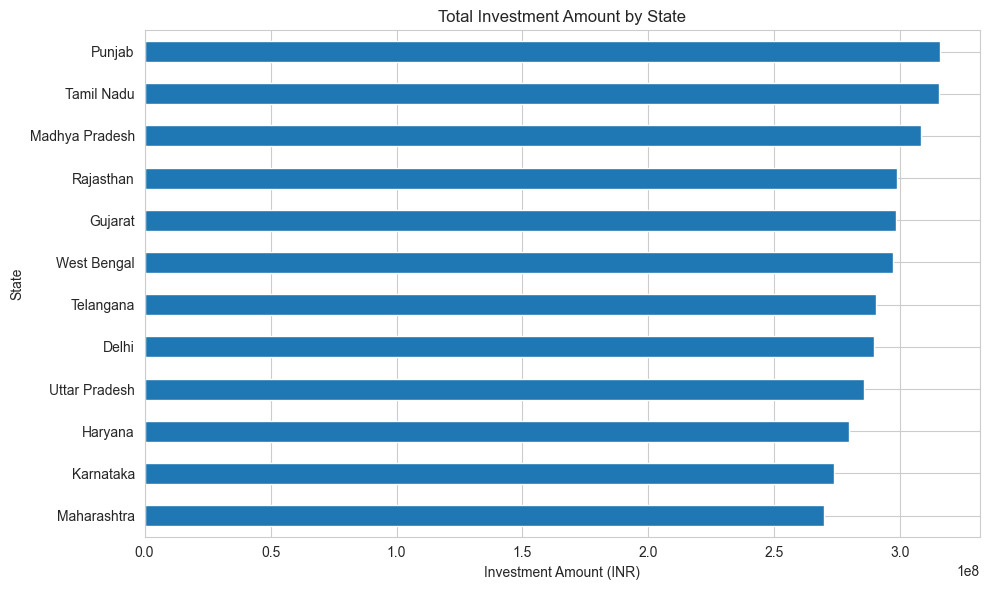

In [32]:
import matplotlib.pyplot as plt

state_amount = (
    transactions.groupby("state")["amount_inr"]
    .sum()
    .sort_values()
)

plt.figure(figsize=(10,6))

state_amount.plot(kind="barh")

plt.title("Total Investment Amount by State")
plt.xlabel("Investment Amount (INR)")
plt.ylabel("State")

plt.tight_layout()
plt.savefig(
    "../reports/state_investment.png",
    bbox_inches="tight"
)
plt.show()

In [33]:
print(transactions["city_tier"].value_counts())

city_tier
T30    21719
B30    11059
Name: count, dtype: int64


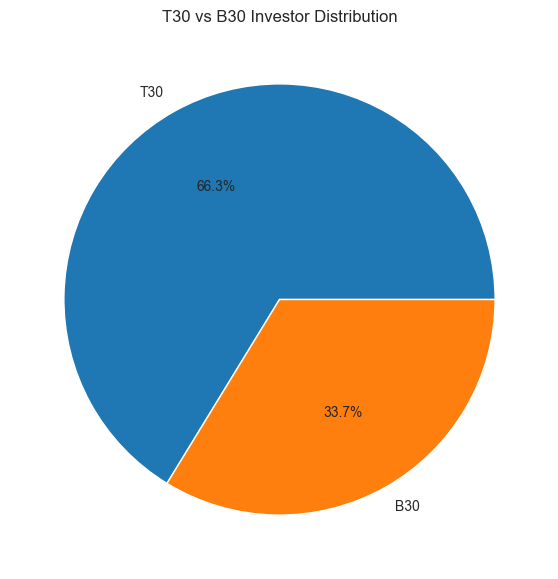

In [34]:
tier_counts = transactions["city_tier"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    tier_counts,
    labels=tier_counts.index,
    autopct="%1.1f%%"
)

plt.title("T30 vs B30 Investor Distribution")
plt.savefig(
    "../reports/t30_b30_distribution.png",
    bbox_inches="tight"
)
plt.show()

In [35]:
folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")

print(folio.columns.tolist())
print(folio.head())

['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']
     month  total_folios_crore  equity_folios_crore  debt_folios_crore  \
0  2022-01               13.26                 9.28               1.86   
1  2022-04               13.91                 9.74               1.95   
2  2022-07               13.85                 9.69               1.94   
3  2022-10               14.12                 9.88               1.98   
4  2023-01               14.81                10.37               2.07   

   hybrid_folios_crore  others_folios_crore  
0                 0.80                 1.33  
1                 0.83                 1.39  
2                 0.83                 1.38  
3                 0.85                 1.41  
4                 0.89                 1.48  


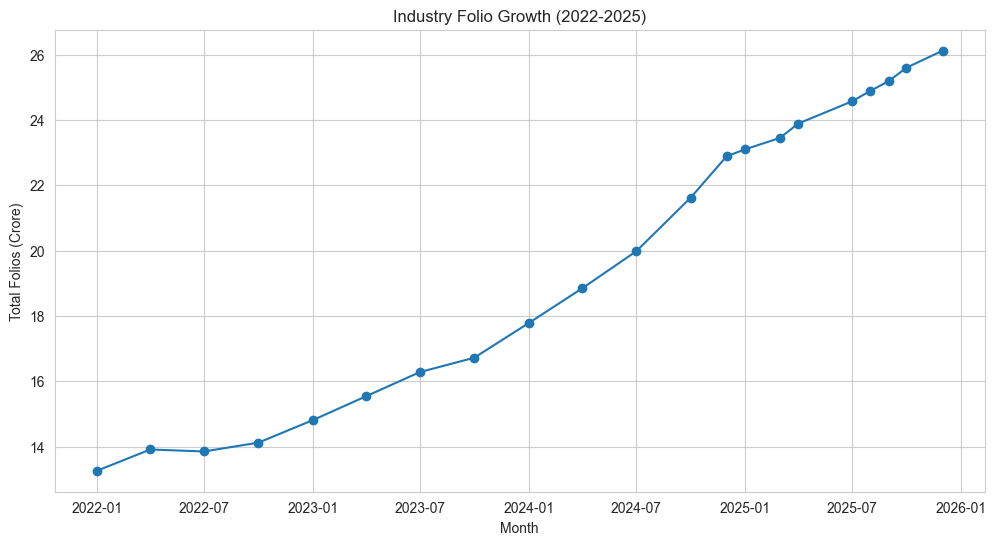

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")

folio["month"] = pd.to_datetime(folio["month"])

plt.figure(figsize=(12,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o"
)

plt.title("Industry Folio Growth (2022-2025)")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")

plt.grid(True)

plt.savefig(
    "../reports/folio_growth.png",
    bbox_inches="tight"
)

plt.show()

In [39]:
performance = pd.read_csv(
    "../data/processed/clean_scheme_performance.csv"
)

print(performance.columns.tolist())

['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade', 'negative_sharpe_flag', 'expense_ratio_valid']


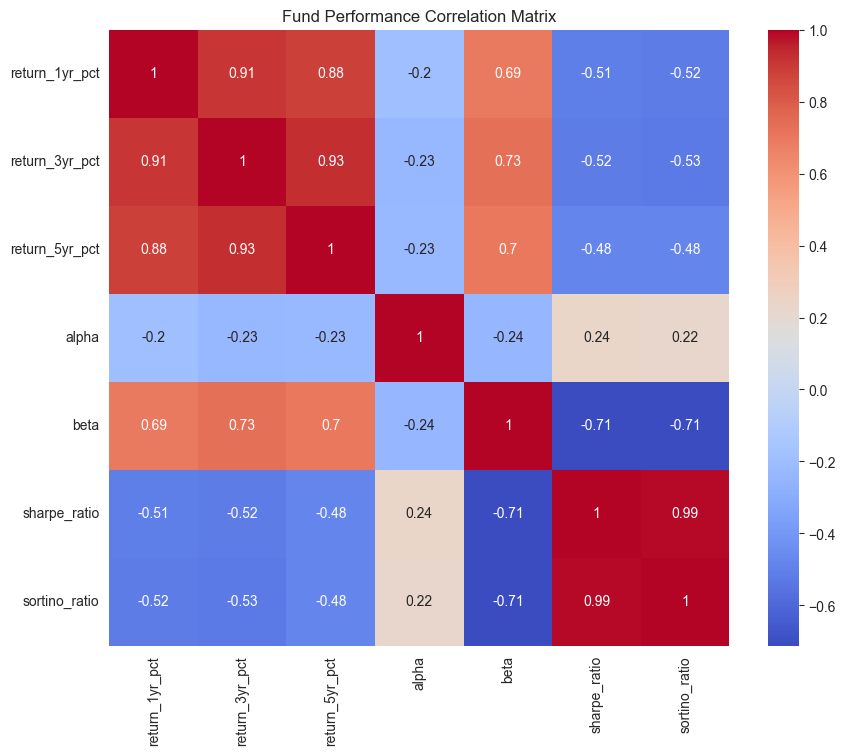

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = performance[
    [
        "return_1yr_pct",
        "return_3yr_pct",
        "return_5yr_pct",
        "alpha",
        "beta",
        "sharpe_ratio",
        "sortino_ratio"
    ]
].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Fund Performance Correlation Matrix")
plt.savefig(
    "../reports/correlation_matrix.png",
    bbox_inches="tight"
)

plt.show()

In [41]:
holdings = pd.read_csv(
    "../data/raw/09_portfolio_holdings.csv"
)

print(holdings.columns.tolist())
print(holdings.head())

['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']
   amfi_code stock_symbol                stock_name       sector  weight_pct  \
0     119551    POWERGRID    Power Grid Corporation    Utilities       13.85   
1     119551     HDFCBANK             HDFC Bank Ltd      Banking       11.19   
2     119551       GRASIM     Grasim Industries Ltd  Diversified        9.90   
3     119551      DRREDDY  Dr. Reddy's Laboratories       Pharma        4.76   
4     119551   ASIANPAINT          Asian Paints Ltd       Paints       10.25   

   market_value_cr  current_price_inr portfolio_date  
0           737.09            6011.08     2025-12-31  
1            88.97            1074.65     2025-12-31  
2           208.45            5964.59     2025-12-31  
3           161.32            3748.82     2025-12-31  
4           725.90            1321.45     2025-12-31  


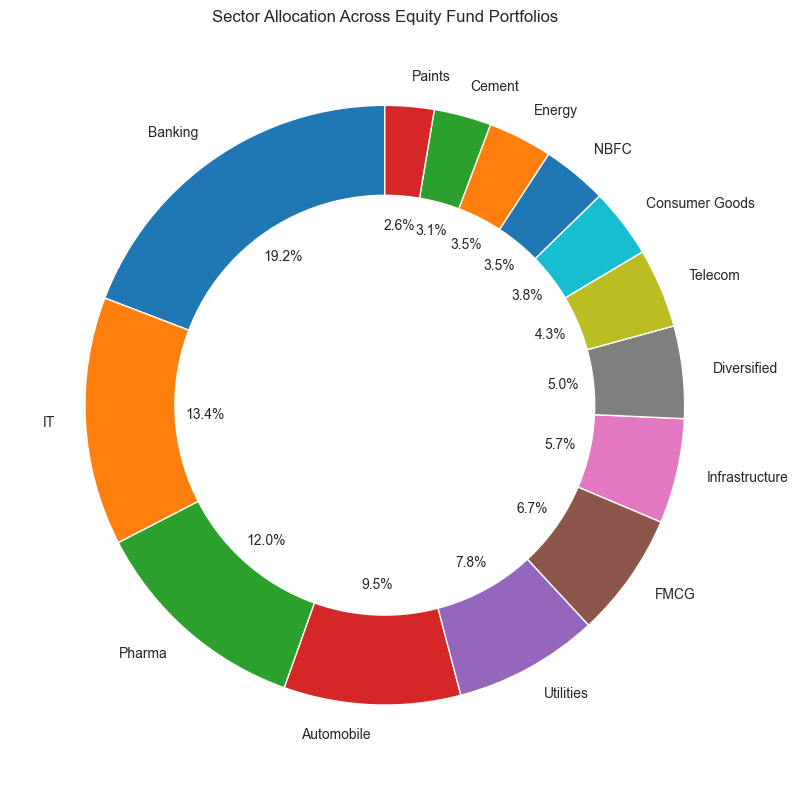

In [42]:
import matplotlib.pyplot as plt

# Sum weights by sector
sector_data = (
    holdings.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,8))

plt.pie(
    sector_data,
    labels=sector_data.index,
    autopct="%1.1f%%",
    startangle=90
)

# Create donut hole
centre_circle = plt.Circle(
    (0,0),
    0.70,
    fc="white"
)

fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Sector Allocation Across Equity Fund Portfolios")

plt.tight_layout()
plt.savefig(
    "../reports/sector_allocation.png",
    bbox_inches="tight"
)

plt.show()

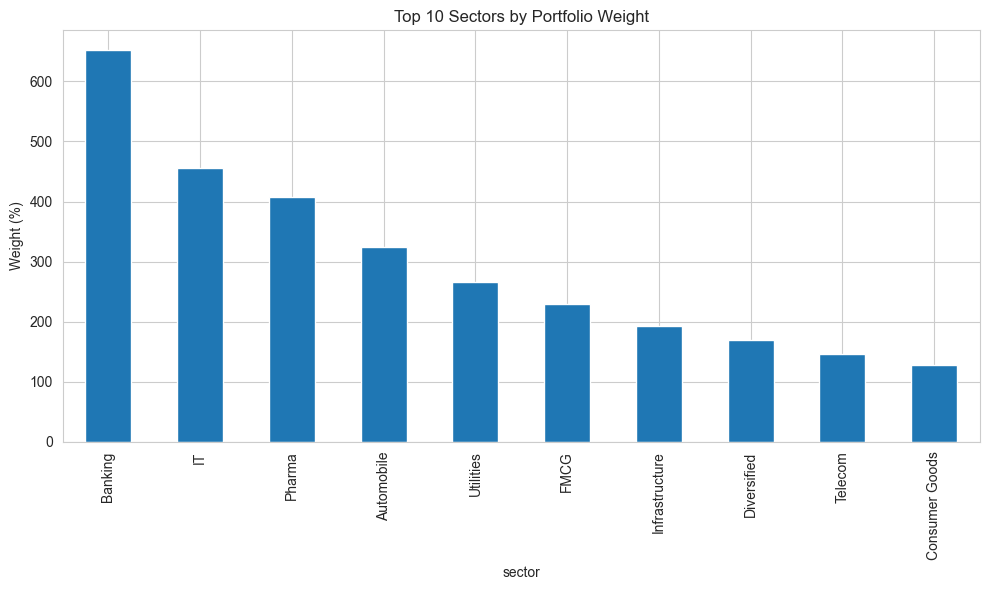

In [44]:
top_sectors = (
    holdings.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

top_sectors.plot(kind="bar")

plt.title("Top 10 Sectors by Portfolio Weight")
plt.ylabel("Weight (%)")

plt.tight_layout()
plt.savefig(
    "../reports/sectors_by_portfolio_weight.png",
    bbox_inches="tight"
)
plt.show()

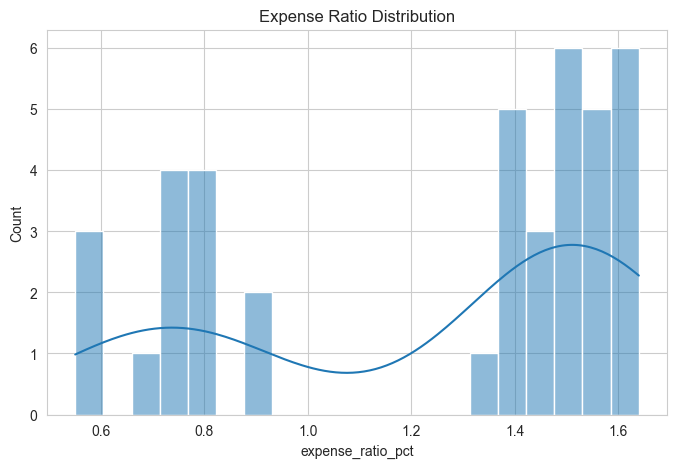

In [45]:
plt.figure(figsize=(8,5))

sns.histplot(
    performance["expense_ratio_pct"],
    bins=20,
    kde=True
)

plt.title("Expense Ratio Distribution")
plt.savefig(
    "../reports/expense_ratio.png",
    bbox_inches="tight"
)
plt.show()

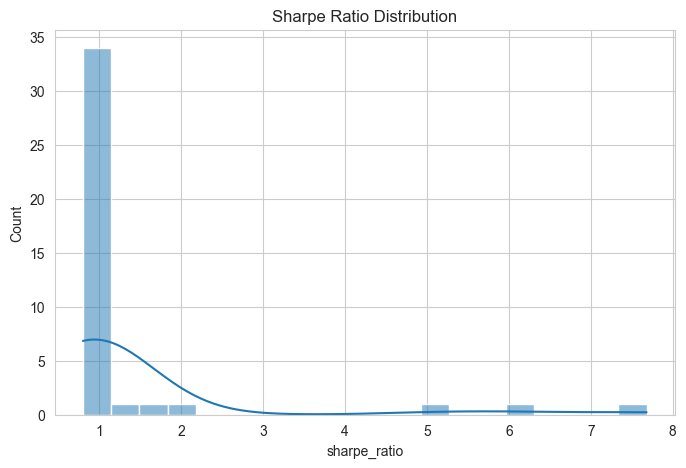

In [46]:
plt.figure(figsize=(8,5))

sns.histplot(
    performance["sharpe_ratio"],
    bins=20,
    kde=True
)

plt.title("Sharpe Ratio Distribution")
plt.savefig(
    "../reports/sharpe_ratio.png",
    bbox_inches="tight"
)
plt.show()

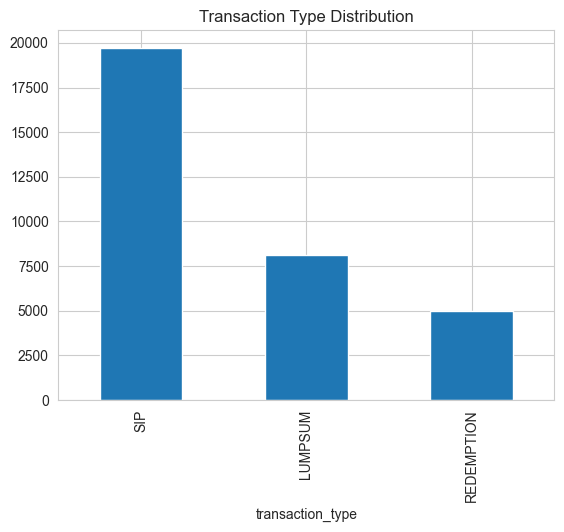

In [47]:
transactions["transaction_type"].value_counts().plot(
    kind="bar"
)

plt.title("Transaction Type Distribution")
plt.savefig(
    "../reports/transaction_type.png",
    bbox_inches="tight"
)
plt.show()

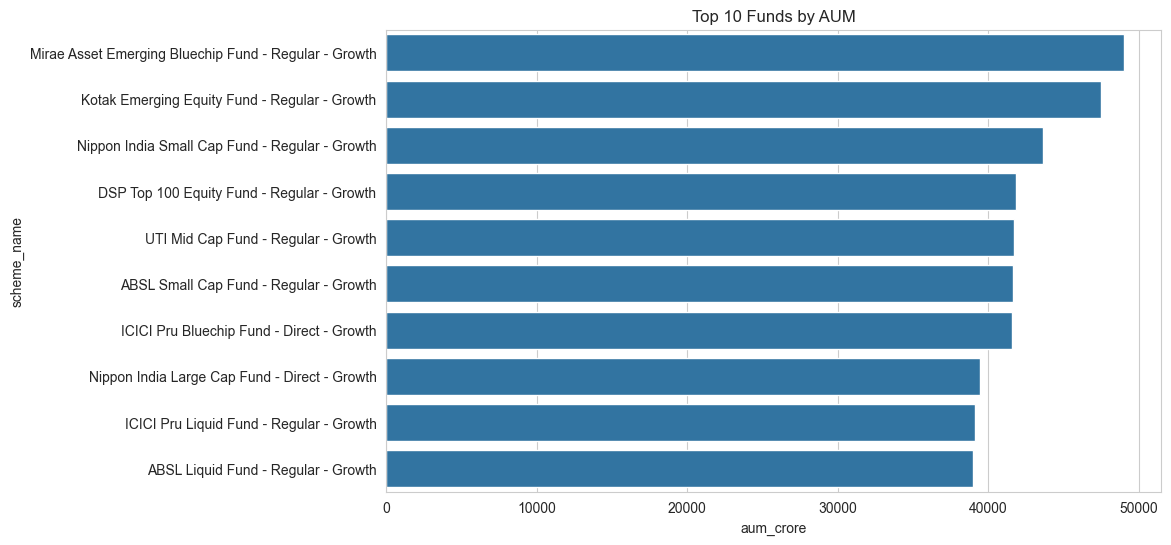

In [48]:
top_funds = performance.nlargest(
    10,
    "aum_crore"
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_funds,
    x="aum_crore",
    y="scheme_name"
)

plt.title("Top 10 Funds by AUM")
plt.savefig(
    "../reports/top_funds_by_aum.png",
    bbox_inches="tight"
)
plt.show()